# Convolutional Neural Network 모델 정의

In [1]:
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
# Conv2d 생성
layer = nn.Conv2d(
    in_channels=3,  # 입력 데이터의 channel 개수. 입력 tensor의 shape: (batch_size, channel, height, width)
    out_channels=5, # 필터의 개수 (output feature map의 개수)
    kernel_size=3,  # 필터의 크기 (3, 3)
    stride=1,       # 계산을 위하 이동 크기. 좌->우: 1칸씩, 상->하: 1칸 (default: 1)
    padding=1,      # 패팅 크기 (정수: 상하/좌우 동일할 패팅크기를 명시 - 0(default): 패딩추가 안함.)
                    # "same": 입력 size와 동일한 size의 출력이 나오도록 알아서 패딩을 추가.
)
# 다음 layer 생성
# layer2 = nn.Conv2d(
#     in_channels=5, # 이전 Conv2d의 out_channels 값이 다음 Conv2d의 in_channels 값이 된다.
# )

In [3]:
input_data = torch.ones(1, 3, 10, 10) # batch크기, channel수, heigth, width
output = layer(input_data)
output.shape

torch.Size([1, 5, 10, 10])

In [4]:
### Conv2d의 weigth 의 shape
layer.weight.shape
# [5:필터개수-out_channels,
#  3:channel수-in_channel,
#  3:height-kernel_size,
#  3:width-kernel_size]

torch.Size([5, 3, 3, 3])

In [5]:
layer.bias.shape # channel당 1개씩 bias가 추가.

torch.Size([5])

In [6]:
pool_layer = nn.MaxPool2d(
    kernel_size=2, # 값을 추출하는 영역 크기(2, 2), default: 2
    stride=2,      # 다음 값을 추출하기위해서 몇칸을 이동할지.(default: kernel_size)
    padding=0
    # 값을 추출할 영역이 kernel_size보다 작을 경우 추출할지 여부.
    # 0-추출을 하지 않겠다.
)

In [7]:
print(input_data.shape)
pool_output = pool_layer(input_data)
print(pool_output.shape)

torch.Size([1, 3, 10, 10])
torch.Size([1, 3, 5, 5])


In [8]:
input_data = torch.randn(1, 1, 5, 5)

print(input_data.shape)
pool_output = pool_layer(input_data)
print(pool_output.shape)

torch.Size([1, 1, 5, 5])
torch.Size([1, 1, 2, 2])


In [12]:
input_data, pool_output

(tensor([[[[-0.5656,  0.5273, -0.9710, -0.6531,  0.7257],
           [ 0.1140,  0.9963, -0.1601, -0.7997,  1.4350],
           [ 0.7643,  0.4322, -2.1219,  1.0699,  0.5307],
           [ 1.0194,  1.5774,  0.3781, -0.1860, -0.0985],
           [-1.5352,  0.2654,  0.3891, -0.4418, -0.3327]]]]),
 tensor([[[[ 0.9963, -0.1601],
           [ 1.5774,  1.0699]]]]))

In [9]:
input_data[0, 0]

tensor([[-0.5656,  0.5273, -0.9710, -0.6531,  0.7257],
        [ 0.1140,  0.9963, -0.1601, -0.7997,  1.4350],
        [ 0.7643,  0.4322, -2.1219,  1.0699,  0.5307],
        [ 1.0194,  1.5774,  0.3781, -0.1860, -0.0985],
        [-1.5352,  0.2654,  0.3891, -0.4418, -0.3327]])

In [10]:
pool_output

tensor([[[[ 0.9963, -0.1601],
          [ 1.5774,  1.0699]]]])

# MNIST

In [13]:
%pip install torchinfo

In [14]:
import os

import torch
from torch import nn
import torchinfo

import matplotlib.pyplot as plt
import numpy as np

from module.data import load_mnist_dataset, load_fashion_mnist_dataset
from module.train import fit

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [15]:
# 하이퍼파라미터 지정
EPOCH = 20
BATCH_SIZE = 256
LEARNING_RATE = 0.001
DATA_ROOT_DIR = "datasets"

## Data 준비

In [16]:
train_loader = load_mnist_dataset(DATA_ROOT_DIR, BATCH_SIZE, True)
test_loader = load_mnist_dataset(DATA_ROOT_DIR, BATCH_SIZE, False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.05MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 65.3kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.08MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.25MB/s]


In [17]:
len(train_loader), len(test_loader) # step 수

(235, 40)

In [18]:
train_loader.dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: datasets
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )

## CNN 모델 정의

In [22]:
# CNN - layer block
## ConvolutionLayer -> Activation -> Pooling Layer
## ConvolutionLayer -> Activation -> ConvolutionLayer -> Activation-> Pooling Layer

### ConvolutionLayer -> (BatchNormalization) -> Activation -> (Dropout) -> Pooling Layer

## 구조: filter 개수는 늘려주고(channel-depth) feature map의 size는 줄이는 방식으로 구성.
# depth: Conv2d,  size: MaxPool2d

class CNNModel(nn.Module):

    def __init__(self, dropout_rate=0.2):
        # 모델을 구성하는 Layer함수들을 초기화(객체 생성)
        super().__init__()
        # block 단위로 정의 - nn.Sequential()

        self.b1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,   # 입력 데이터의 channel 개수. 입력 tensor의 shape: (batch_size, channel, height, width)
                                 # grayscale 이미지 -> channel수: 1, color: 3
                out_channels=32, # 필터의 개수 (output feature map의 개수)
                kernel_size=3,   # 필터의 크기, (3, 3)이 요즘은 표준.
                stride=1,        # 계산을 위하 이동 크기. 좌->우: 1칸씩, 상->하: 1칸 (default: 1)
                padding="same"   # 패팅 크기 (정수: 상하/좌우 동일할 패팅크기를 명시 - 0(default): 패딩추가 안함.)
                                 # "same": 입력 size와 동일한 size의 출력이 나오도록 알아서 패딩을 추가.
            ),
            nn.BatchNorm2d(32), # Conv: out_channels
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.MaxPool2d(
                kernel_size=2, # 값을 추출하는 영역 크기(2, 2) - default: 2
                stride=2       # 다음 값을 추출하기위해서 몇칸을 이동할지.(default: kernel_size)
            )
        )

        self.b2 = nn.Sequential(
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding="same"
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.b3 = nn.Sequential(
            nn.Conv2d(
                in_channels=64,
                out_channels=128,   # 전체 인풋 사이즈에서 계속 사이즈가 작아지니까 채널수는 늘어나는 것.
                kernel_size=3,
                stride=1,
                padding="same"
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=1)
        )
        # 추론기(분류기) - Fully Conntected Layer(nn.Liear)
        self.classifier = nn.Sequential(
            nn.Flatten(),   # 128채널을 flatten.
            nn.Linear(in_features=4*4*128, out_features=10) # 최종 결과를 반환할 Layer. out_features=class개수
        )   # feature 사이즈는 계산을 해봐야 함.. 그러니까,,, 추론기 부분을 빼고 모델 완성해서 인포 보고 개수 맞춰주면 편함.

    def forward(self, X):
        output = self.b1(X)
        output = self.b2(output)
        output = self.b3(output)
        output = self.classifier(output)
        return output

In [24]:
model = CNNModel(dropout_rate=0.3)
model

CNNModel(
  (b1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (b2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (b3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (classifier)

In [25]:
torchinfo.summary(model, (1, 1, 28, 28)) # 분류기 부분 빼고 코드를 돌려보고 in_feature 수를 찾아서 추론기 부분 추가해도 됨 !

Layer (type:depth-idx)                   Output Shape              Param #
CNNModel                                 [1, 10]                   --
├─Sequential: 1-1                        [1, 32, 14, 14]           --
│    └─Conv2d: 2-1                       [1, 32, 28, 28]           320
│    └─BatchNorm2d: 2-2                  [1, 32, 28, 28]           64
│    └─ReLU: 2-3                         [1, 32, 28, 28]           --
│    └─Dropout: 2-4                      [1, 32, 28, 28]           --
│    └─MaxPool2d: 2-5                    [1, 32, 14, 14]           --
├─Sequential: 1-2                        [1, 64, 7, 7]             --
│    └─Conv2d: 2-6                       [1, 64, 14, 14]           18,496
│    └─BatchNorm2d: 2-7                  [1, 64, 14, 14]           128
│    └─ReLU: 2-8                         [1, 64, 14, 14]           --
│    └─Dropout: 2-9                      [1, 64, 14, 14]           --
│    └─MaxPool2d: 2-10                   [1, 64, 7, 7]             --
├─Sequent

## Train

In [26]:
# 모델
model = model.to(device)

# loss 함수
loss_fn = nn.CrossEntropyLoss()
# 정답: One hot encoding처리, 추론값: Softmax 적용

# 옵티마이저
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [27]:
os.makedirs("saved_models", exist_ok=True)

In [28]:
save_path = "saved_models/mnist_cnn_model.pt"
result = fit(
    train_loader, test_loader, model, loss_fn, optimizer, EPOCH,
    save_model_path=save_path,
    device=device,
    mode="multi"
)

Epoch[1/20] - Train loss: 0.15126 Train Accucracy: 0.98307 || Validation Loss: 0.14195 Validation Accuracy: 0.98550
저장: 1 - 이전 : inf, 현재: 0.14194883052259682
Epoch[2/20] - Train loss: 0.10505 Train Accucracy: 0.98868 || Validation Loss: 0.10145 Validation Accuracy: 0.98940
저장: 2 - 이전 : 0.14194883052259682, 현재: 0.1014459440484643
Epoch[3/20] - Train loss: 0.12011 Train Accucracy: 0.97960 || Validation Loss: 0.11684 Validation Accuracy: 0.97970
Epoch[4/20] - Train loss: 0.06769 Train Accucracy: 0.99128 || Validation Loss: 0.06743 Validation Accuracy: 0.99010
저장: 4 - 이전 : 0.1014459440484643, 현재: 0.06742648161016404
Epoch[5/20] - Train loss: 0.06629 Train Accucracy: 0.98980 || Validation Loss: 0.06449 Validation Accuracy: 0.98940
저장: 5 - 이전 : 0.06742648161016404, 현재: 0.06449221367947758
Epoch[6/20] - Train loss: 0.05849 Train Accucracy: 0.99165 || Validation Loss: 0.06248 Validation Accuracy: 0.98900
저장: 6 - 이전 : 0.06449221367947758, 현재: 0.06247978829778731
Epoch[7/20] - Train loss: 0.0467

In [29]:
len(test_loader)

40

In [31]:
model = torch.load(save_path, weights_only=False)

In [32]:
# 최종 평가
from module.train import test_multi_classification
loss, acc = test_multi_classification(
    test_loader, model, loss_fn, device
)
loss, acc

(0.02799590223003179, 0.9928)

In [33]:
%pip install pillow

In [38]:
## 정성적 평가 - 실제 image 파일로 확인
from PIL import Image
img = Image.open("sample_data/eight.png")
type(img)

PIL.PngImagePlugin.PngImageFile

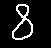

In [39]:
img

In [53]:
from torchvision import transforms
from PIL import Image

def predict(path, model):
    img = Image.open(path)

    # color -> grayscale
    img = img.convert('L') # 'L': grayscale, "RGB": color

    # resize << 왜 안해도 된다고 ?
    input_tensor = transforms.Resize((28, 28))(img)

    # PIL.Image -> torch.Tensor  변환, 정규화 (0 ~ 1)
    input_tensor = transforms.ToTensor()(input_tensor)

    # batch 축(dummy 축)을 추가.
    input_tensor = input_tensor.unsqueeze(dim=0)
    # print(type(input_tensor))
    # input_tensor.shape
    model.eval()
    model = model.to(device)
    input_tensor = input_tensor.to(device)

    with torch.no_grad():
        result = model(input_tensor)
    sm = nn.Softmax(dim=-1)
    result_proba = sm(result)
    final_result = result_proba.max(dim=-1)
    return {"class":final_result.indices[0],
            "확률":final_result.values[0]}

In [54]:
from glob import glob

img_path_list = glob("sample_data/*.png")
for img_path in img_path_list:
    result = predict(img_path, model)
    print(f"{img_path}, 추론class: {result['class']}, 확률: {result['확률']}")

sample_data/one.png, 추론class: 1, 확률: 0.6390278339385986
sample_data/seven2.png, 추론class: 1, 확률: 0.6460794806480408
sample_data/three2.png, 추론class: 3, 확률: 0.6745439767837524
sample_data/five.png, 추론class: 5, 확률: 0.7065258622169495
sample_data/four.png, 추론class: 4, 확률: 0.9996247291564941
sample_data/eight2.png, 추론class: 8, 확률: 0.9888907670974731
sample_data/seven.png, 추론class: 7, 확률: 0.6243609189987183
sample_data/eight.png, 추론class: 8, 확률: 0.9761473536491394
sample_data/two.png, 추론class: 2, 확률: 0.9984560012817383
sample_data/three.png, 추론class: 2, 확률: 0.38639137148857117
